In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv(r"C:\Users\rpap9\OneDrive\Desktop\ML Project\Breast Cancer.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
print("\n--- Initial Data Inspection ---")

# Display basic information (data types, non-null counts)
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())


--- Initial Data Inspection ---

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 n

In [5]:
# Handle potential unnamed column
# Create a copy to clearly track changes
df_cleaned = df.copy()
potential_unnamed_col = 'Unnamed: 32'

if potential_unnamed_col in df_cleaned.columns:
    print(f"\nDropping the '{potential_unnamed_col}' column.")
    df_cleaned = df_cleaned.drop(potential_unnamed_col, axis=1)
    print(f"'{potential_unnamed_col}' column dropped.")
    print("\nColumns after dropping:", df_cleaned.columns.tolist()) # Use tolist() for cleaner print
else:
    print(f"\nNo '{potential_unnamed_col}' column found to drop.")

# Verify missing values again
print("\nMissing Values after potential cleanup:")
print(df_cleaned.isnull().sum())


Dropping the 'Unnamed: 32' column.
'Unnamed: 32' column dropped.

Columns after dropping: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Missing Values after potential cleanup:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean


--- Target Variable Analysis ---

Diagnosis Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Percentage Benign (B): 62.74%
Percentage Malignant (M): 37.26%


C:\Users\rpap9\AppData\Local\Temp\ipykernel_6488\11471129.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df_cleaned, palette='viridis', order=['B', 'M']) # Specify order


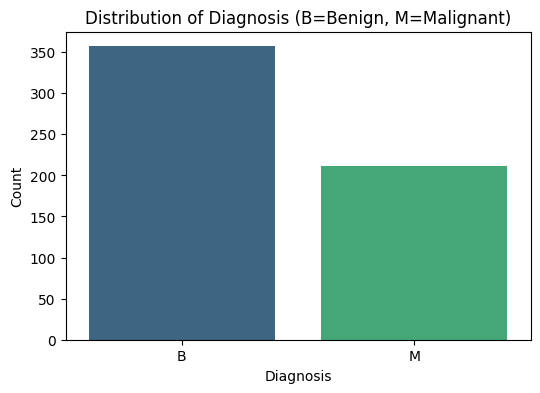

In [6]:
# Analyze the Target Variable ('diagnosis')
print("\n--- Target Variable Analysis ---")

# Distribution of the target variable
print("\nDiagnosis Distribution:")
diagnosis_counts = df_cleaned['diagnosis'].value_counts()
print(diagnosis_counts)
print(f"\nPercentage Benign (B): {diagnosis_counts['B'] / len(df_cleaned) * 100:.2f}%")
print(f"Percentage Malignant (M): {diagnosis_counts['M'] / len(df_cleaned) * 100:.2f}%")

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df_cleaned, palette='viridis', order=['B', 'M']) # Specify order
plt.title('Distribution of Diagnosis (B=Benign, M=Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


--- Feature Correlation Analysis ---


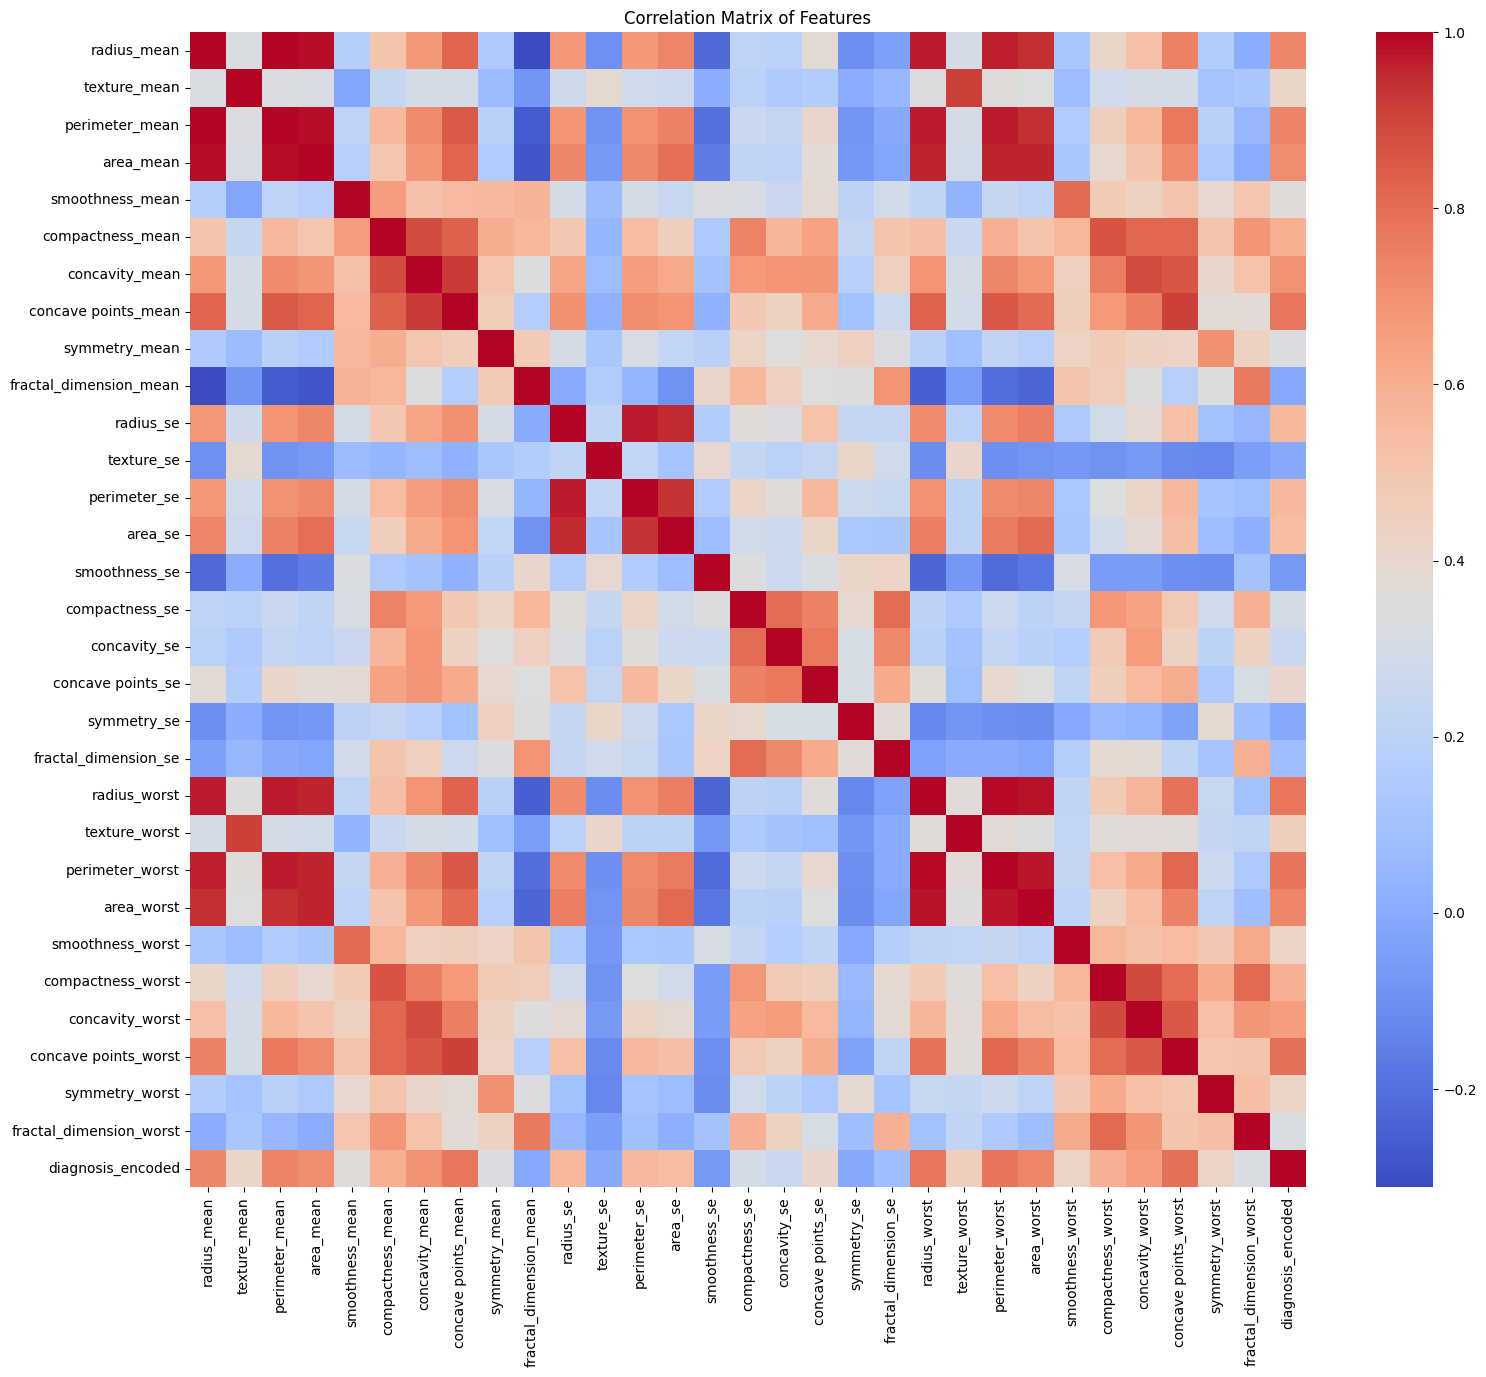


Correlation with Encoded Diagnosis (1=Malignant, 0=Benign):
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
sym

In [7]:
# Explore Feature Correlations
print("\n--- Feature Correlation Analysis ---")

# Temporarily encode diagnosis for correlation analysis (M=1, B=0)
temp_df = df_cleaned.copy()
le_temp = LabelEncoder()
temp_df['diagnosis_encoded'] = le_temp.fit_transform(temp_df['diagnosis'])

# Prepare DataFrame for correlation matrix (drop non-numeric/original target)
temp_corr_df = temp_df.drop(['id', 'diagnosis'], axis=1)

# Calculate and plot correlation matrix
corr_matrix = temp_corr_df.corr()
plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".1f") # Use fmt if using annot=True later
plt.title('Correlation Matrix of Features')
plt.show()

# Show correlations specifically with the encoded target variable
print("\nCorrelation with Encoded Diagnosis (1=Malignant, 0=Benign):")
target_correlation = corr_matrix['diagnosis_encoded'].sort_values(ascending=False)
print(target_correlation.drop('diagnosis_encoded')) # Exclude self-correlation

# Cleanup temporary variable
del temp_df, temp_corr_df, le_temp, corr_matrix, target_correlation

In [8]:
# Drop the 'id' column
print("\n--- Data Preprocessing: Dropping 'id' ---")
if 'id' in df_cleaned.columns:
    df_processed = df_cleaned.drop('id', axis=1)
    print("'id' column dropped.")
    print("Current columns:", df_processed.columns.tolist())
else:
    df_processed = df_cleaned.copy()
    print("'id' column not found or already dropped.")


--- Data Preprocessing: Dropping 'id' ---
'id' column dropped.
Current columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [9]:
# Encode the Target Variable ('diagnosis')
print("\n--- Data Preprocessing: Encoding Target Variable ---")
label_encoder = LabelEncoder()

# Fit and transform the diagnosis column
df_processed['diagnosis_encoded'] = label_encoder.fit_transform(df_processed['diagnosis'])

# Show the mapping
print("\nDiagnosis mapping:")
for i, class_label in enumerate(label_encoder.classes_):
    print(f"{class_label} -> {i}")

# Drop the original categorical 'diagnosis' column
df_processed_encoded = df_processed.drop('diagnosis', axis=1)

print("\nDataFrame head after encoding target:")
print(df_processed_encoded.head())


--- Data Preprocessing: Encoding Target Variable ---

Diagnosis mapping:
B -> 0
M -> 1

DataFrame head after encoding target:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980      

In [10]:
# Separate Features (X) and Target (y)
print("\n--- Data Preprocessing: Separating Features and Target ---")
X = df_processed_encoded.drop('diagnosis_encoded', axis=1)
y = df_processed_encoded['diagnosis_encoded']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)


--- Data Preprocessing: Separating Features and Target ---
Shape of features (X): (569, 30)
Shape of target (y): (569,)


In [11]:
# Split Data into Training and Testing Sets
print("\n--- Data Preprocessing: Train-Test Split ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Train target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))


--- Data Preprocessing: Train-Test Split ---
Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Train target distribution:
 diagnosis_encoded
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Test target distribution:
 diagnosis_encoded
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [12]:
# Scale Numerical Features
print("\n--- Data Preprocessing: Feature Scaling ---")
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional: Display scaled data glimpse
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("\nScaled Training Data (first 5 rows):")
print(X_train_scaled_df.head())
del X_train_scaled_df # Clean up temporary DataFrame


--- Data Preprocessing: Feature Scaling ---

Scaled Training Data (first 5 rows):
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     0.518559      0.891826        0.424632   0.383925        -0.974744   
1    -0.516364     -1.639710       -0.541349  -0.542961         0.476219   
2    -0.368118      0.455515       -0.388250  -0.402970        -1.432979   
3     0.205285      0.726168        0.400330   0.070612         0.243253   
4     1.243005      0.194195        1.210377   1.206652        -0.111442   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0         -0.689772       -0.688586            -0.398175      -1.039155   
1         -0.631834       -0.604281            -0.303075       0.521543   
2         -0.383927       -0.342175            -0.765459      -0.850857   
3          2.203585        2.256094             1.213233       0.818474   
4          0.051348        0.732962             0.713767      -0.427187   

   fracta

In [13]:
# Train Basic Logistic Regression Model
print("\n--- Basic Model Training ---")
basic_log_reg = LogisticRegression(random_state=42, max_iter=5000) # Use sufficient max_iter
basic_log_reg.fit(X_train_scaled, y_train)
print("Basic Logistic Regression model trained.")

# Predict using the basic model
y_pred_basic = basic_log_reg.predict(X_test_scaled)

# Evaluate the basic model
print("\n--- Basic Model Evaluation ---")
accuracy_basic = accuracy_score(y_test, y_pred_basic)
print(f"Basic Model Accuracy: {accuracy_basic * 100:.2f}%")
print("\nBasic Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_basic))
print("\nBasic Model Classification Report:")
print(classification_report(y_test, y_pred_basic, target_names=label_encoder.classes_))


--- Basic Model Training ---
Basic Logistic Regression model trained.

--- Basic Model Evaluation ---
Basic Model Accuracy: 96.49%

Basic Model Confusion Matrix:
[[71  1]
 [ 3 39]]

Basic Model Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [14]:
# Hyperparameter Tuning using GridSearchCV
print("\n--- Hyperparameter Tuning (GridSearchCV) ---")

# Define the parameter grid
# C: Inverse of regularization strength (smaller values specify stronger regularization)
# penalty: Type of regularization
# solver: Algorithm to use in the optimization problem. 'liblinear' is good for small datasets and supports l1/l2.
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' works well with small datasets and both L1/L2
}

# Instantiate the Logistic Regression model (without setting params here)
log_reg_tuning = LogisticRegression(random_state=42, max_iter=5000)

# Instantiate GridSearchCV
# cv=5 means 5-fold cross-validation
# scoring='accuracy' tells it to optimize for accuracy
grid_search = GridSearchCV(estimator=log_reg_tuning, 
                           param_grid=param_grid, 
                           cv=5, 
                           scoring='accuracy', 
                           n_jobs=-1) # Use all available CPU cores

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Get the best parameters and best score
print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%")

# Get the best estimator (the model trained with the best parameters)
best_log_reg = grid_search.best_estimator_
print("\nTuned Logistic Regression model obtained.")


--- Hyperparameter Tuning (GridSearchCV) ---

Best Parameters found: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 97.36%

Tuned Logistic Regression model obtained.



--- Tuned Model Evaluation ---
Tuned Model Accuracy: 98.25%

Tuned Model Confusion Matrix:
[[72  0]
 [ 2 40]]


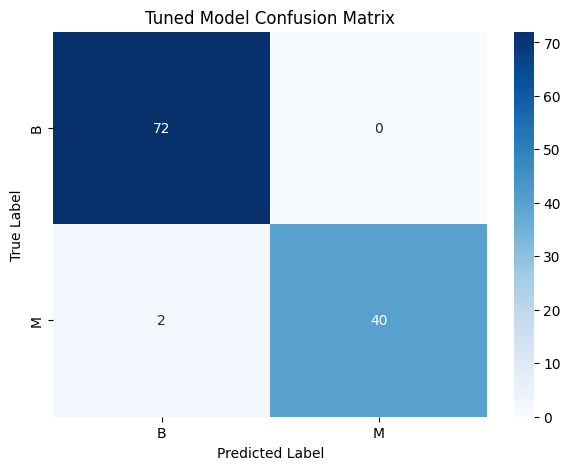


Tuned Model Classification Report:
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [15]:
# Evaluate the Tuned Model
print("\n--- Tuned Model Evaluation ---")

# Make predictions using the best model from GridSearchCV
y_pred_tuned = best_log_reg.predict(X_test_scaled)

# Calculate Accuracy
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Accuracy: {accuracy_tuned * 100:.2f}%")

# Generate Confusion Matrix
print("\nTuned Model Confusion Matrix:")
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(cm_tuned)

# Visualize Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Tuned Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate Classification Report
print("\nTuned Model Classification Report:")
report_tuned = classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_)
print(report_tuned)

In [16]:
# Conclusion
print("\n--- Final Conclusion ---")
print(f"The Basic Logistic Regression model achieved {accuracy_basic * 100:.2f}% accuracy.")
print(f"The Tuned Logistic Regression model (Best Params: {grid_search.best_params_}) achieved {accuracy_tuned * 100:.2f}% accuracy.")

improvement = accuracy_tuned - accuracy_basic
print(f"Tuning resulted in an accuracy change of {improvement * 100:.2f}%.")

if accuracy_tuned > 0.90:
    print("\nThe tuned model performance EXCEEDS the 90% accuracy target.")
else:
    print("\nThe tuned model performance IS BELOW the 90% accuracy target.")

print("\nKey evaluation points for the tuned model:")
print(f"- Correctly predicted Benign (True Negatives): {cm_tuned[0,0]}")
print(f"- Incorrectly predicted Malignant (False Positives): {cm_tuned[0,1]}")
print(f"- Incorrectly predicted Benign (False Negatives): {cm_tuned[1,0]}")
print(f"- Correctly predicted Malignant (True Positives): {cm_tuned[1,1]}")
print("Focusing on minimizing False Negatives (predicting Malignant as Benign) is often critical in medical contexts.")


--- Final Conclusion ---
The Basic Logistic Regression model achieved 96.49% accuracy.
The Tuned Logistic Regression model (Best Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}) achieved 98.25% accuracy.
Tuning resulted in an accuracy change of 1.75%.

The tuned model performance EXCEEDS the 90% accuracy target.

Key evaluation points for the tuned model:
- Correctly predicted Benign (True Negatives): 72
- Incorrectly predicted Malignant (False Positives): 0
- Incorrectly predicted Benign (False Negatives): 2
- Correctly predicted Malignant (True Positives): 40
Focusing on minimizing False Negatives (predicting Malignant as Benign) is often critical in medical contexts.
